In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [7]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../data/olist_orders_dataset.csv'

In [5]:
# For Reference 

orders.head()
#products.head()
#sellers.head()
#reviews.head()
#payments.head()
#items.head()
#customers.head()
#translation.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


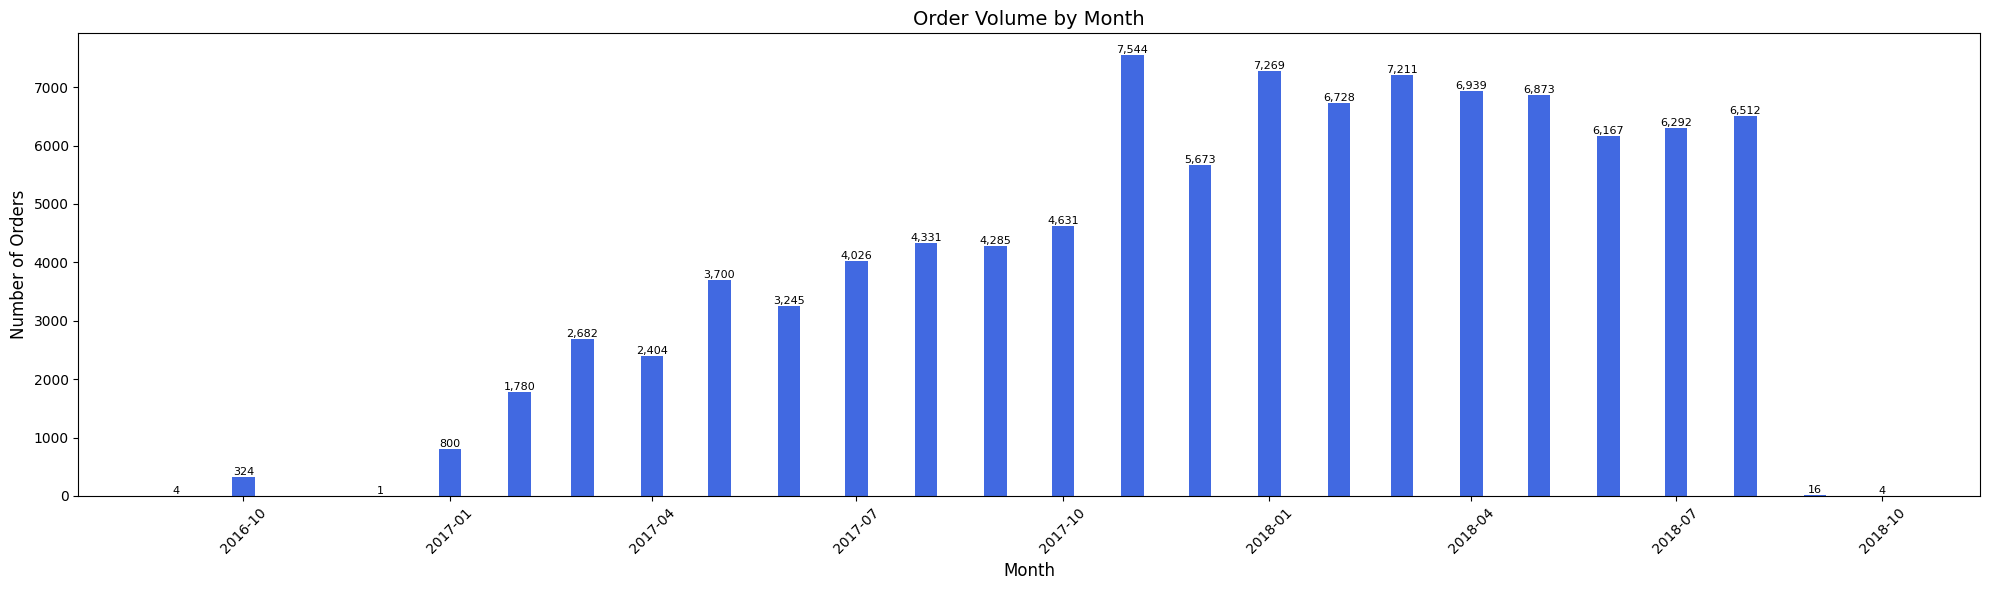

In [211]:
# Question 1: Number of Orders by Month

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

by_month = orders.groupby('purchase_month', as_index=False)['order_id'].count()
by_month['purchase_month'] = by_month['purchase_month'].dt.to_timestamp()
by_month = by_month.sort_values('purchase_month')

plt.figure(figsize=(20, 6))
bars = plt.bar(by_month['purchase_month'], by_month['order_id'], color='royalblue', width=10)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Order Volume by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


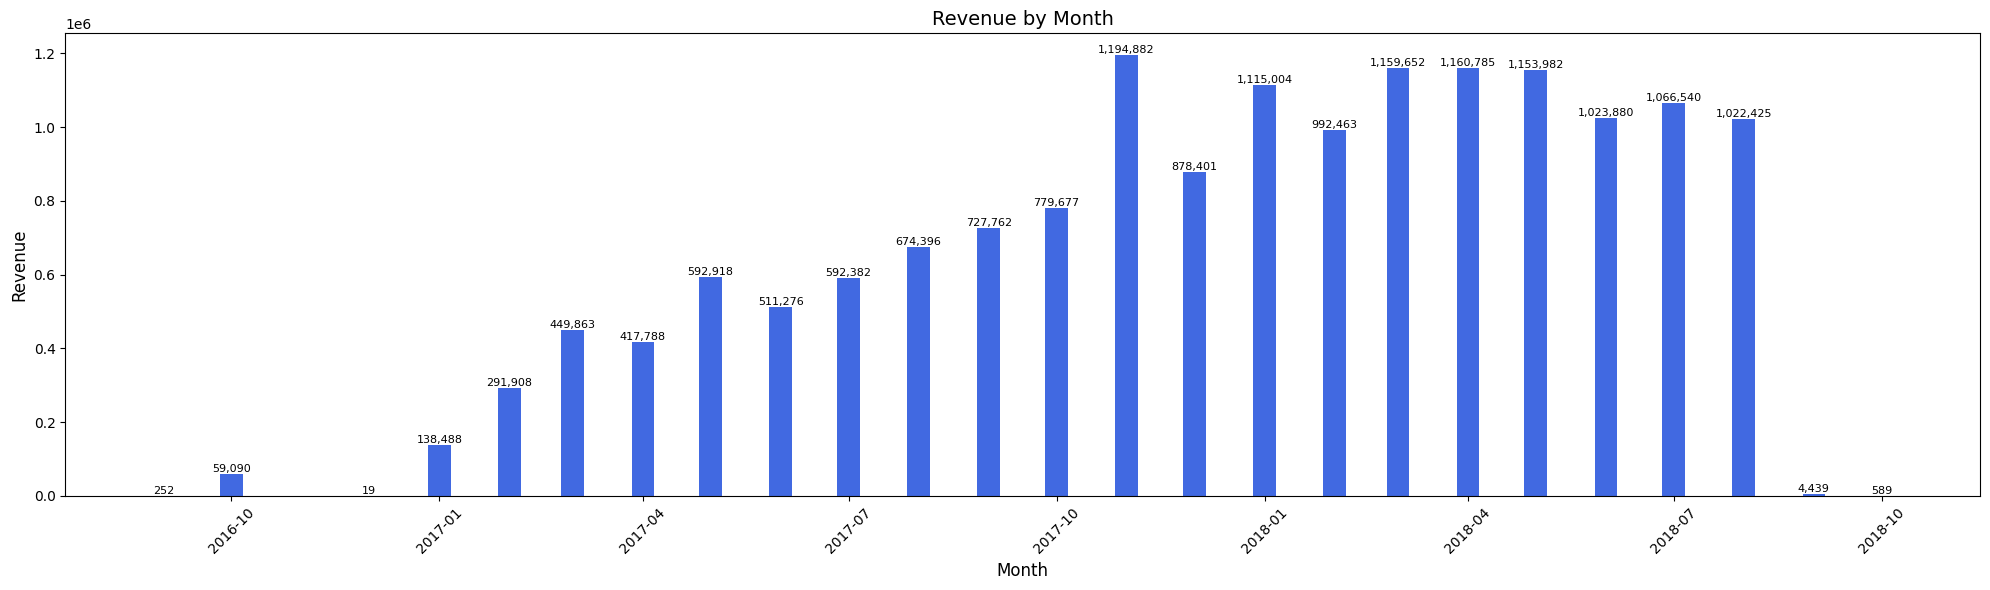

np.float64(16008872.12)

In [212]:
# Question 2: Total Revenue by Month

payment_for_orders = pd.merge(orders, payments, on='order_id', how='left')

by_month = payment_for_orders.groupby('purchase_month', as_index=False)['payment_value'].sum()
by_month['purchase_month'] = by_month['purchase_month'].dt.to_timestamp()
by_month = by_month.sort_values('purchase_month')

plt.figure(figsize=(20, 6))
bars = plt.bar(by_month['purchase_month'], by_month['payment_value'], color='royalblue', width=10)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Revenue by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

by_month['payment_value'].sum()

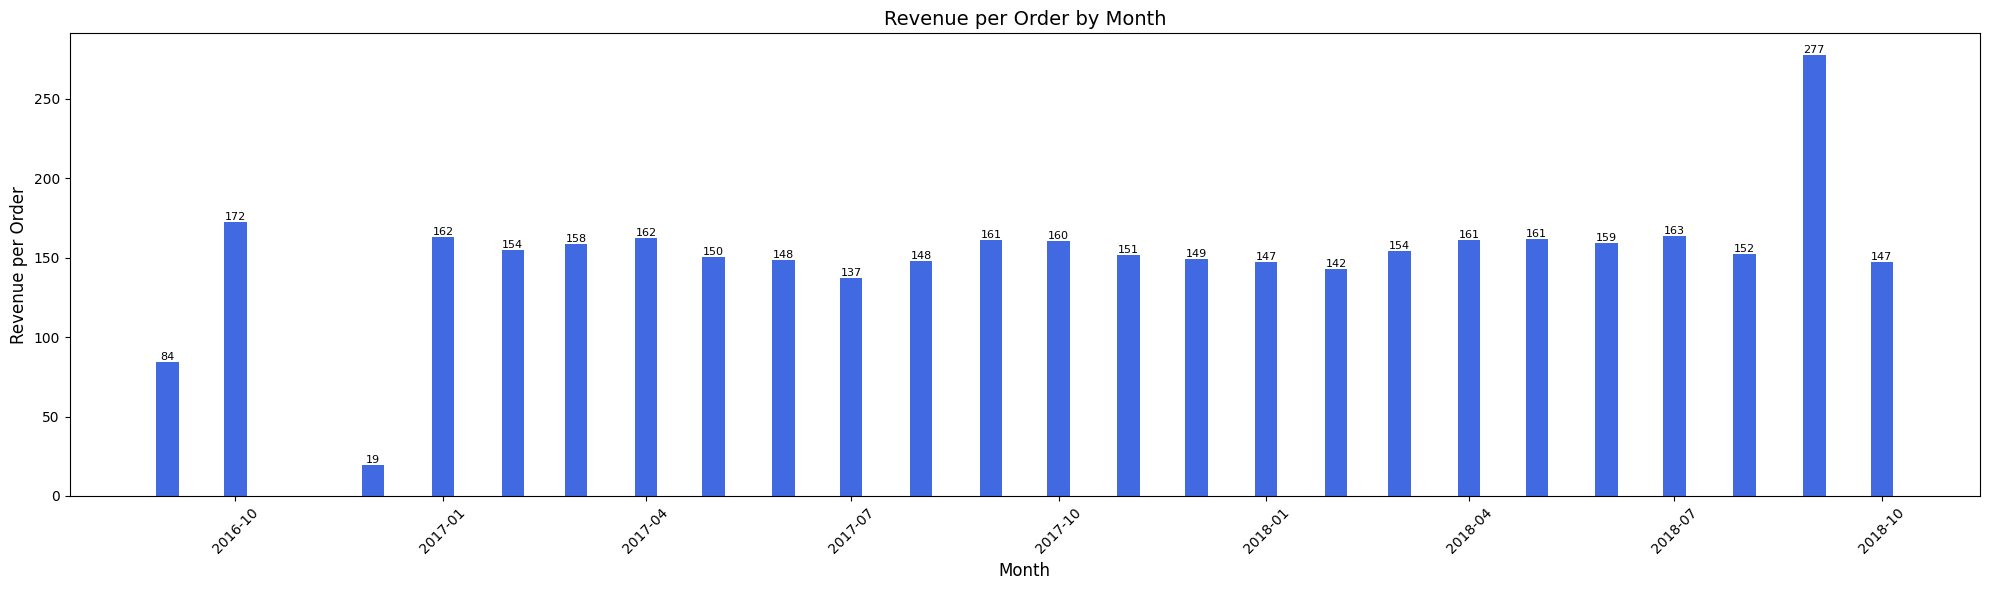

In [213]:
# Question 3: Average Order Value (Revenue Per Order) by Month

by_month = payment_for_orders.groupby('purchase_month', as_index=False)['payment_value'].mean()
by_month['purchase_month'] = by_month['purchase_month'].dt.to_timestamp()
by_month = by_month.sort_values('purchase_month')

plt.figure(figsize=(20, 6))
bars = plt.bar(by_month['purchase_month'], by_month['payment_value'], color='royalblue', width=10)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Revenue per Order by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue per Order', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [214]:
# Question 4: Top 10 Product Categories

translated_products = pd.merge(products, translation, on='product_category_name', how='left')
product_sales = pd.merge(items, translated_products, on='product_id', how='left')
total_1 = product_sales['freight_value'].sum()

top_10 = product_sales.groupby('product_category_name_english', as_index=False, dropna=False)['price'].sum().sort_values(by='price', ascending=False)
total_2 = product_sales['price'].sum()
top_10['Percent of Revenue'] = (top_10['price'] / total_2).round(2) * 100
top_10['price'] = top_10['price'].map('${:,.2f}'.format)

top_10.head(10)


,product_category_name_english,price,Percent of Revenue
43,health_beauty,"$1,258,681.34",9.0
70,watches_gifts,"$1,205,005.68",9.0
7,bed_bath_table,"$1,036,988.68",8.0
65,sports_leisure,"$988,048.97",7.0
15,computers_accessories,"$911,954.32",7.0
39,furniture_decor,"$729,762.49",5.0
20,cool_stuff,"$635,290.85",5.0
49,housewares,"$632,248.66",5.0
5,auto,"$592,720.11",4.0
42,garden_tools,"$485,256.46",4.0


In [215]:
# Question 5: Average Review Score by top 10 revenue categories

# Get average review score per order first
avg_reviews = reviews.groupby('order_id', as_index=False)['review_score'].mean()

# Then merge onto product_sales
top_10_score = pd.merge(product_sales, avg_reviews, on='order_id', how='left')

# Then groupby category
top_10_score = top_10_score.groupby('product_category_name_english', as_index=False)[['price', 'review_score']].agg({'price':'sum', 'review_score':'mean'}).round(2).sort_values(by='price', ascending=False)

top_10_score.head(10)


,product_category_name_english,price,review_score
43,health_beauty,1258681.34,4.14
70,watches_gifts,1205005.68,4.02
7,bed_bath_table,1036988.68,3.90
65,sports_leisure,988048.97,4.11
15,computers_accessories,911954.32,3.93
39,furniture_decor,729762.49,3.91
20,cool_stuff,635290.85,4.15
49,housewares,632248.66,4.05
5,auto,592720.11,4.06
42,garden_tools,485256.46,4.05


In [216]:
# Question 6: Late Deliveries for bed_bath_table, computers_accessories, and furniture_decor

order_level = orders.merge(items[['order_id','product_id']], on='order_id', how='left')
order_level = order_level.merge(products[['product_id','product_category_name']], on='product_id', how='left')
product_sales_orders = order_level.merge(translation, on='product_category_name', how='left')

product_sales_orders = product_sales_orders[(product_sales_orders['product_category_name_english'] == 'furniture_decor') | 
                                            (product_sales_orders['product_category_name_english'] == 'bed_bath_table') | 
                                            (product_sales_orders['product_category_name_english'] == 'computers_accessories')]

product_sales_orders['late'] = product_sales_orders['order_delivered_customer_date'].case_when(
    [(product_sales_orders['order_delivered_customer_date'] > product_sales_orders['order_estimated_delivery_date'], 1), 
     (product_sales_orders['order_delivered_customer_date'] <= product_sales_orders['order_estimated_delivery_date'], 0)])

late_orders = product_sales_orders.groupby('product_category_name_english', as_index=False)['late'].mean()
late_orders['late'] = (late_orders['late'] * 100).round(2)
late_orders

,product_category_name_english,late
0,bed_bath_table,8.399525
1,computers_accessories,7.771817
2,furniture_decor,8.431373


In [217]:
# Question 7: Late Delivery Rate across all categories

order_level = orders.merge(items[['order_id','product_id']], on='order_id', how='left')
order_level = order_level.merge(products[['product_id','product_category_name']], on='product_id', how='left')
product_sales_orders = order_level.merge(translation, on='product_category_name', how='left')

product_sales_orders['late'] = product_sales_orders['order_delivered_customer_date'].case_when(
    [(product_sales_orders['order_delivered_customer_date'] > product_sales_orders['order_estimated_delivery_date'], 1), 
     (product_sales_orders['order_delivered_customer_date'] <= product_sales_orders['order_estimated_delivery_date'], 0)])

late_orders = product_sales_orders['late'].mean().round(3)*100
print(f'Late Delivery Base Rate: {late_orders}%')

Late Delivery Base Rate: 7.9%


In [218]:
# Question 8: Revenue Concentration in top 10% of Sellers

seller_rev = items.groupby('seller_id', as_index=False)['price'].sum()
top_10_percent = seller_rev[seller_rev['price'] >= seller_rev['price'].quantile(0.9)].sort_values('price', ascending=False)
print(round(top_10_percent['price'].sum() / items['price'].sum()*100, 2))
top_10_percent.head(310)

67.56


,seller_id,price
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1013,53243585a1d6dc2643021fd1853d8905,222776.05
881,4a3ca9315b744ce9f8e9374361493884,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89
...,...,...
580,31344c16881c08a8a72c6d2eb29918c1,9615.70
2793,e7df4cd29ab5abab70fb0783ddb53987,9608.70
1426,73a63f72308aa20a46f4b1632018f196,9606.80
2145,b2ac621f0d0322434d04a12b078b9369,9575.50


In [219]:
# Question 9: Top 5 States by # of Sellers & Share of Total Sellers by State

by_state = sellers.groupby('seller_state', as_index=False)['seller_id'].count()
by_state['Percent of Total'] = round(by_state['seller_id'] / by_state['seller_id'].sum()*100, 2)
by_state.sort_values('seller_id', ascending=False).head()

,seller_state,seller_id,Percent of Total
22,SP,1849,59.74
15,PR,349,11.28
8,MG,244,7.88
20,SC,190,6.14
16,RJ,171,5.53


In [220]:
# Question 10: Top 5 States by # of Customers & Share of Total Customers by State

by_state = customers.groupby('customer_state', as_index=False)['customer_id'].count()
by_state['Percent of Total'] = round(by_state['customer_id'] / by_state['customer_id'].sum()*100, 2)
by_state.sort_values('customer_id', ascending=False).head()

,customer_state,customer_id,Percent of Total
25,SP,41746,41.98
18,RJ,12852,12.92
10,MG,11635,11.70
22,RS,5466,5.50
17,PR,5045,5.07


In [221]:
# Question 11: Average Review Score by Early / Late / On Time 

avg_reviews = reviews.groupby('order_id', as_index=False)['review_score'].mean()
delivery = orders[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date']]
merged = pd.merge(orders, reviews, how='left', on='order_id')

merged['delivery_category'] = merged['order_delivered_customer_date'].case_when([(merged['order_delivered_customer_date'] > merged['order_estimated_delivery_date'], 'Late'), 
(merged['order_delivered_customer_date'] <= merged['order_estimated_delivery_date'], 'On Time')])

grouped = merged.groupby('delivery_category', as_index=False)[['order_id', 'review_score']].agg({'order_id': 'count', 'review_score': 'mean'}).round(2)
grouped



,delivery_category,order_id,review_score
0,Late,7866,2.57
1,On Time,89139,4.29


In [222]:
# Question 12: Average days between purchase and actual delivery date by State

orders['time_to_delivery'] = pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_purchase_timestamp'])

merged = pd.merge(orders, customers, on='customer_id', how='left')

merged.groupby('customer_state', as_index=False)[['order_id', 'time_to_delivery']].agg({'order_id': 'count', 'time_to_delivery': 'mean'}).sort_values(by='time_to_delivery', ascending=False).head(10)


,customer_state,order_id,time_to_delivery
21,RR,46,29 days 09:18:03.975609756
3,AP,68,27 days 04:26:29.850746268
2,AM,148,26 days 10:13:25.613793103
1,AL,413,24 days 13:03:09.103274559
13,PA,975,23 days 18:33:00.021141649
9,MA,747,21 days 13:45:05.167364016
24,SE,350,21 days 12:28:29.707462686
5,CE,1336,21 days 06:23:52.394057857
0,AC,81,21 days 00:51:25.600000
14,PB,536,20 days 10:14:32.721470019


In [223]:
# Question 13: Average Freight Value per Order by Customer State

merged = pd.merge(orders, items, on='order_id', how='left')
merged_2 = pd.merge(merged, customers, on='customer_id', how='left')

merged_2.groupby('customer_state', as_index=False)[['order_id', 'freight_value']].agg({'order_id': 'count', 'freight_value': 'mean'}).sort_values(by='freight_value', ascending=False).head(10)

,customer_state,order_id,freight_value
21,RR,52,42.984423
14,PB,606,42.723804
20,RO,284,41.069712
0,AC,92,40.073370
16,PI,544,39.147970
9,MA,831,38.257002
26,TO,316,37.246603
24,SE,390,36.653169
1,AL,446,35.843671
13,PA,1085,35.832685


In [224]:
# Question 14: Payment Types & Average # of Installments for CC Payments

payments.groupby('payment_type', as_index=False)[['order_id', 'payment_installments']].agg({'order_id': 'count', 'payment_installments': 'mean'})

,payment_type,order_id,payment_installments
0,boleto,19784,1.000000
1,credit_card,76795,3.507155
2,debit_card,1529,1.000000
3,not_defined,3,1.000000
4,voucher,5775,1.000000


In [225]:
# Question 15: Repeat Customers & Average # of Orders for Repeat Customers

orders_customers = pd.merge(orders, customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

repeats = orders_customers.groupby('customer_unique_id', as_index=False)['order_id'].count()

total_customers = repeats['customer_unique_id'].nunique()
repeat_customers = repeats[repeats['order_id'] > 1]

pct_repeat = round(repeat_customers['customer_unique_id'].nunique() / total_customers * 100, 2)
avg_orders = round(repeat_customers['order_id'].mean(), 2)

print(f'Percentage of repeat customers: {pct_repeat}%')
print(f'Average orders placed by repeat customers: {avg_orders}')

Percentage of repeat customers: 3.12%
Average orders placed by repeat customers: 2.12


In [226]:
# Question 16: Distribution of Review Scores across All Orders

avg_reviews = reviews.groupby('review_score', as_index=False)['order_id'].count().sort_values(by='order_id', ascending=False)
avg_reviews['percentage'] = round(avg_reviews['order_id'] / avg_reviews['order_id'].sum(), 2)
avg_reviews

,review_score,order_id,percentage
4,5,57328,0.58
3,4,19142,0.19
0,1,11424,0.12
2,3,8179,0.08
1,2,3151,0.03


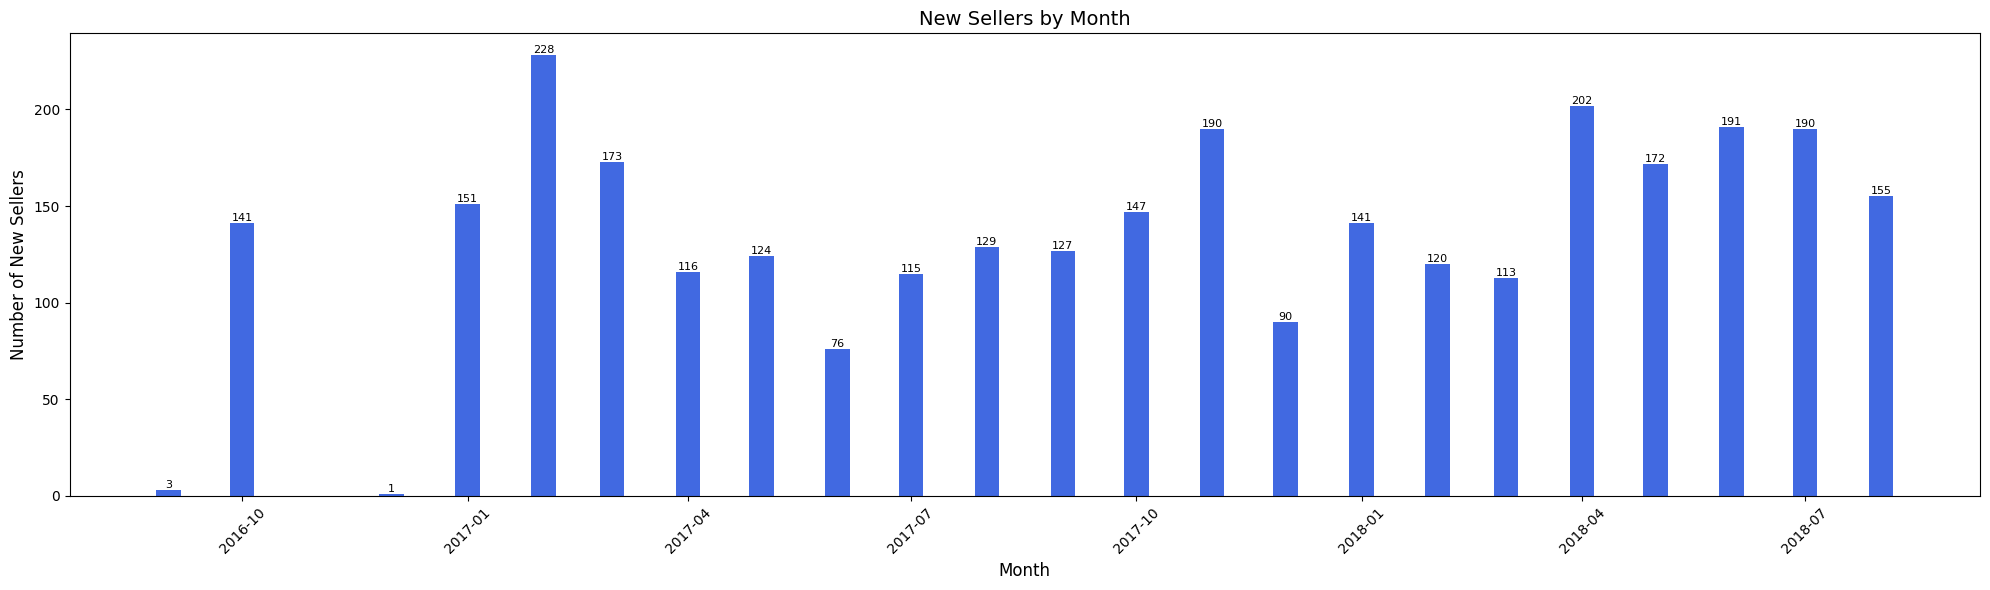

In [227]:
# Question 17: New Seller Count per Month

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders_items = pd.merge(orders, items, on='order_id', how='left')

by_seller = orders_items.groupby('seller_id', as_index=False)['purchase_month'].min()

by_month = by_seller.groupby('purchase_month', as_index=False)['seller_id'].count()
by_month['purchase_month'] = by_month['purchase_month'].dt.to_timestamp()
by_month = by_month.sort_values('purchase_month')

plt.figure(figsize=(20, 6))
bars = plt.bar(by_month['purchase_month'], by_month['seller_id'], color='royalblue', width=10)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('New Sellers by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of New Sellers', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [228]:
# Question 18a: Top 10 States by Total Customer Revenue

merged = pd.merge(orders, items, on='order_id', how='left')
merged_2 = pd.merge(merged, customers, on='customer_id', how='left')

merged_2.groupby('customer_state', as_index=False)['price'].sum().sort_values(by='price', ascending=False).head(10)



,customer_state,price
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76
23,SC,520553.34
4,BA,511349.99
6,DF,302603.94
8,GO,294591.95
7,ES,275037.31


In [229]:
# Question 19: Average Review Score Per State

merged = pd.merge(orders, reviews, on='order_id', how='left')
merged_2 = pd.merge(merged, customers, on='customer_id', how='left')
merged_2.groupby('customer_state', as_index=False)['review_score'].mean().round(2).sort_values(by='review_score', ascending=True)

,customer_state,review_score
21,RR,3.61
1,AL,3.75
9,MA,3.76
24,SE,3.81
13,PA,3.85
5,CE,3.85
4,BA,3.86
18,RJ,3.87
16,PI,3.92
15,PE,4.01


In [230]:
# Question 20: Average Delivery Time in Days for the top 5 Revenue States 

target_states = ['SP', 'RJ', 'MG', 'RS', 'PR']
orders['time_to_delivery'] = pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_purchase_timestamp'])
merged = pd.merge(orders, reviews, on='order_id', how='left')
merged_2 = pd.merge(merged, customers, on='customer_id', how='left')

merged_2 = merged_2[merged_2['customer_state'].isin(target_states)]

merged_2.groupby('customer_state', as_index=False)['time_to_delivery'].mean().sort_values(by='time_to_delivery', ascending=False)

,customer_state,time_to_delivery
3,RS,15 days 07:40:08.261103884
2,RJ,15 days 07:40:03.652579892
0,MG,12 days 00:19:29.058560924
1,PR,12 days 00:00:51.076082557
4,SP,8 days 18:21:21.072618287
